# House Price Prediction — Random Forest vs. XGBoost vs. Linear Regression

This notebook builds on the earlier pipeline work (`house_price_pipeline.ipynb`), which used a `Pipeline` (`StandardScaler` + `OneHotEncoder` + `LinearRegression`) with 2 engineered features and scored **RMSE ≈ $70,306** / **R² ≈ 0.6385**.

Here we:
1. Train a `RandomForestRegressor` and an `XGBRegressor` on the same features
2. Compare all three models' performance
3. Plot and compare feature importances from the two ensemble models
4. Explain how Random Forest and XGBoost combine models differently

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('housing.csv')
df = df.dropna(subset=['total_bedrooms'])

# Same engineered features as the pipeline notebook
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']

numeric_features = ['median_income', 'total_rooms', 'housing_median_age',
                     'population', 'total_bedrooms',
                     'rooms_per_household', 'bedrooms_per_room']
categorical_features = ['ocean_proximity']
target = 'median_house_value'

X = df[numeric_features + categorical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Shared preprocessing (same ColumnTransformer as before)

In [2]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

## Train all three models in identical pipelines

In [3]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1)
}

results = {}
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results[name] = {'RMSE': rmse, 'R2': r2}
    fitted_pipelines[name] = pipe
    print(f"{name:20s} -> RMSE: ${rmse:,.2f} | R^2: {r2:.4f}")

Linear Regression    -> RMSE: $70,306.21 | R^2: 0.6385


Random Forest        -> RMSE: $61,317.83 | R^2: 0.7251


XGBoost              -> RMSE: $63,467.78 | R^2: 0.7054


## Comparison table

In [4]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.rename(columns={'RMSE': 'RMSE ($)', 'R2': 'R\u00b2'})
comparison_df['RMSE ($)'] = comparison_df['RMSE ($)'].round(2)
comparison_df['R\u00b2'] = comparison_df['R\u00b2'].round(4)
comparison_df.to_csv('model_comparison.csv')
comparison_df

,RMSE ($),R²
Linear Regression,70306.21,0.6385
Random Forest,61317.83,0.7251
XGBoost,63467.78,0.7054


## Feature importances — Random Forest vs. XGBoost

In [5]:
feature_names = fitted_pipelines['Random Forest'].named_steps['preprocessor'].get_feature_names_out()

rf_importances = fitted_pipelines['Random Forest'].named_steps['model'].feature_importances_
xgb_importances = fitted_pipelines['XGBoost'].named_steps['model'].feature_importances_

imp_df = pd.DataFrame({
    'feature': feature_names,
    'random_forest': rf_importances,
    'xgboost': xgb_importances
}).sort_values('random_forest', ascending=False)

imp_df

,feature,random_forest,xgboost
0,num__median_income,0.507107,0.156019
8,cat__ocean_proximity_INLAND,0.142807,0.607460
2,num__housing_median_age,0.073772,0.031925
3,num__population,0.067404,0.024997
6,num__bedrooms_per_room,0.060913,0.024562
4,num__total_bedrooms,0.055463,0.032110
5,num__rooms_per_household,0.043040,0.014390
1,num__total_rooms,0.036389,0.014137
11,cat__ocean_proximity_NEAR OCEAN,0.005305,0.031854
7,cat__ocean_proximity_<1H OCEAN,0.004043,0.017902


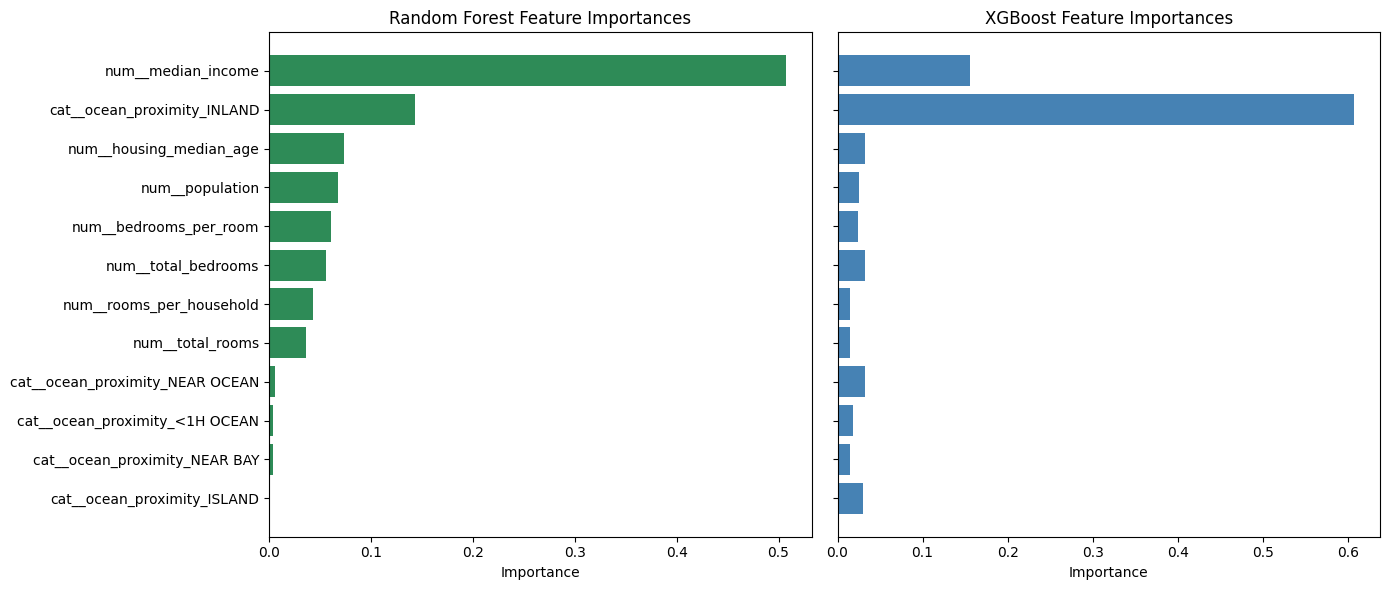

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

rf_sorted = imp_df.sort_values('random_forest')
axes[0].barh(rf_sorted['feature'], rf_sorted['random_forest'], color='seagreen')
axes[0].set_title('Random Forest Feature Importances')
axes[0].set_xlabel('Importance')

xgb_sorted = imp_df.sort_values('xgboost')
axes[1].barh(xgb_sorted['feature'], xgb_sorted['xgboost'], color='steelblue')
axes[1].set_title('XGBoost Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('feature_importances_comparison.png', dpi=150)
plt.show()

The two models actually disagree on the single most important feature. Random Forest puts `median_income` clearly in first place, with importance spread fairly broadly across the other numeric features (`housing_median_age`, `population`, `bedrooms_per_room`, etc.) and very little weight on most of the one-hot `ocean_proximity` categories. XGBoost, by contrast, puts its heaviest weight on `ocean_proximity_INLAND` — whether a block group is inland or not — with `median_income` a clear second and most other features receiving comparatively small importance. This kind of disagreement is normal: Random Forest averages many independently-grown trees, which tends to spread importance across correlated features, while XGBoost's sequential, error-correcting trees can end up leaning heavily on whichever single feature happens to split the residual error most cleanly early on.

## How Random Forest and XGBoost differ 

Random Forest builds many decision trees independently and in parallel, each trained on a random subset of the data and features, and then averages all their predictions together — this "wisdom of the crowd" approach reduces overfitting and variance. XGBoost instead builds trees one at a time in sequence, where each new tree is trained specifically to correct the errors (residuals) left by the trees before it, a technique called gradient boosting. Because of this, XGBoost trees are usually shallower and more specialized, and the model as a whole tends to be more accurate but also more prone to overfitting if not carefully tuned. In short: Random Forest combines many independent "opinions," while XGBoost builds an increasingly refined single "opinion" step by step.

## Save the best-performing pipeline

In [7]:
best_name = comparison_df['R\u00b2'].astype(float).idxmax()
best_pipeline = fitted_pipelines[best_name]
joblib.dump(best_pipeline, 'house_price_best_pipeline.joblib', compress=3)
print(f"Best model: {best_name} -> saved to house_price_best_pipeline.joblib")

Best model: Random Forest -> saved to house_price_best_pipeline.joblib
